<a href="https://colab.research.google.com/github/Arpansen79/Python-/blob/main/Logistic_Regression_(Loan_Approval_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

---

### Q1. Data Loading & Understanding



**a) Load the dataset into Python.**

In [ ]:
# Replace 'loan_data.csv' with your actual dataset file path or URL
df = pd.read_csv('loan_data.csv')

**b) Display the first 5 rows.**

In [ ]:
display(df.head())

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


**c) Check the shape of the dataset.**

In [ ]:
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 2000 rows and 8 columns.


**d) Display the data types of each column.**

In [ ]:
print(df.dtypes)

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


In [ ]:
target_col = 'loan_approved'
print(f"Target column set to: {target_col}")

---

### Correcting numerical feature names and using `target_col` consistently

---

### Q2. Data Cleaning



**a) Check for missing values in the dataset.**

In [ ]:
print(df.isnull().sum())

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


**b) Handle missing values appropriately.**
*Note: A standard approach is to fill numerical missing values with the median and categorical with the mode.*

In [ ]:
# Filling numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Filling categorical columns with mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after treatment:\n", df.isnull().sum())

Missing values after treatment:
 name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


**c) Identify categorical columns present in the dataset.**

In [ ]:
print("Categorical Columns:", list(cat_cols))

Categorical Columns: ['name', 'city']


---

### Q3. Exploratory Data Analysis (EDA)



**a) Plot the distribution of the target variable.**

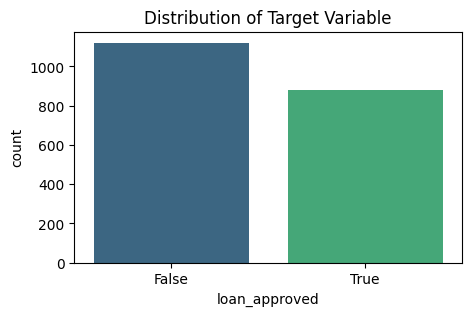

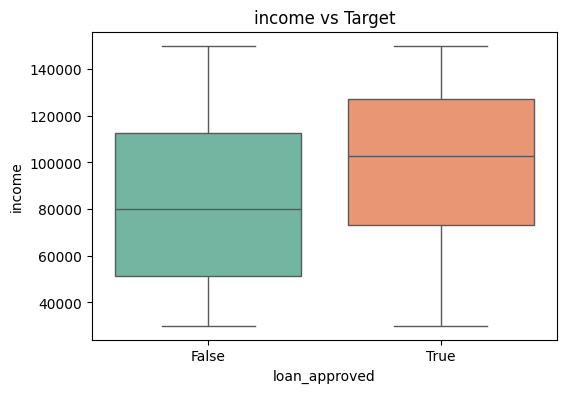

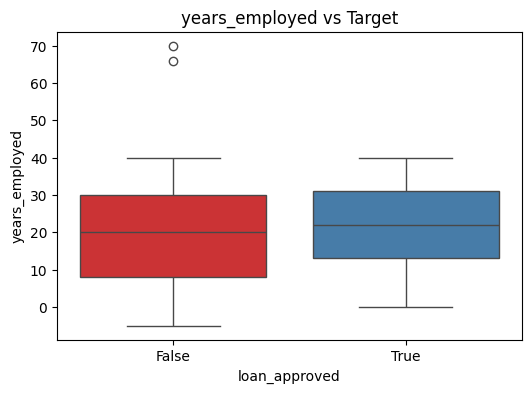

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

MY_ACTUAL_TARGET_COLUMN = 'loan_approved'

# a) Plot the distribution of the target variable
plt.figure(figsize=(5, 3))
sns.countplot(x=MY_ACTUAL_TARGET_COLUMN, data=df, palette='viridis')
plt.title('Distribution of Target Variable')
plt.show()

# b) Analyze relationship between one numerical feature and target
sample_num_col = [c for c in num_cols if c != MY_ACTUAL_TARGET_COLUMN][0]
plt.figure(figsize=(6, 4))
sns.boxplot(x=MY_ACTUAL_TARGET_COLUMN, y=sample_num_col, data=df, palette='Set2')
plt.title(f'{sample_num_col} vs Target')
plt.show()

# c) Analyze the relationship between Years of Employment and the target variable
emp_col = [c for c in df.columns if 'employ' in c.lower()]
emp_col = emp_col[0] if emp_col else sample_num_col # fallback if name differs

plt.figure(figsize=(6, 4))
sns.boxplot(x=MY_ACTUAL_TARGET_COLUMN, y=emp_col, data=df, palette='Set1')
plt.title(f'{emp_col} vs Target')
plt.show()

**b) Analyze the relationship between one numerical feature and the target variable.**

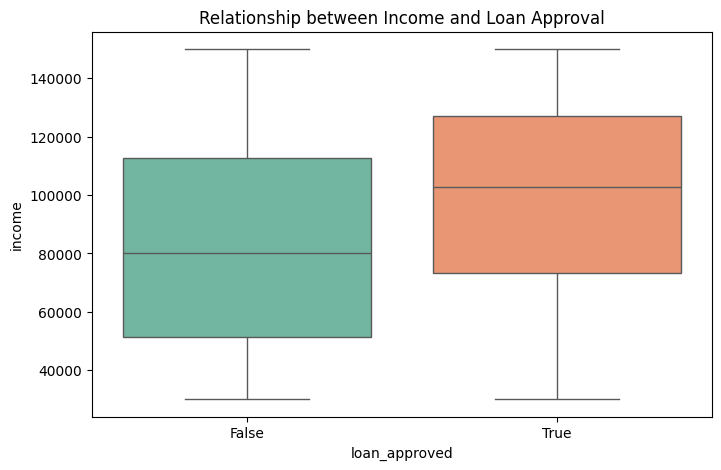

In [ ]:
# Using 'income' as a numerical feature for analysis
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_approved', y='income', data=df, palette='Set2')
plt.title('Relationship between Income and Loan Approval')
plt.show()

**c) Analyze the relationship between Years of Employment and the target variable.**

In [ ]:
# Replace 'Years_of_Employment' with the exact column name from your dataset
plt.figure(figsize=(8, 5))
sns.boxplot(x=target_col, y='Years_of_Employment', data=df, palette='Set1')
plt.title('Relationship between Years of Employment and Loan Approval')
plt.show()

---

### Q4. Outlier Detection and Treatment



**a) Detect outliers in numerical columns using the IQR method.**

In [ ]:
def detect_outliers(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    print(f"{feature}: {len(outliers)} outliers detected.")
    return lower_bound, upper_bound

for col in num_cols:
    detect_outliers(df, col)

income: 0 outliers detected.
credit_score: 3 outliers detected.
loan_amount: 0 outliers detected.
years_employed: 2 outliers detected.
points: 0 outliers detected.


**b) Treat outliers using capping techniques.**

In [ ]:
def cap_outliers(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping values
    data[feature] = np.where(data[feature] < lower_bound, lower_bound, data[feature])
    data[feature] = np.where(data[feature] > upper_bound, upper_bound, data[feature])

for col in num_cols:
    cap_outliers(df, col)

---

### Q5. Convert Target and Drop Columns



**Convert target variables into numerical format and drop unnecessary columns.**

In [ ]:
# Ensure the target column variable is correct
target_col = 'loan_approved'

# Converting target variable (Boolean/String to 1/0)
# Since your data currently shows boolean (True/False), we can convert it to integer
df[target_col] = df[target_col].astype(int)

# Dropping unnecessary columns like Customer Name (which usually doesn't help predictions)
if 'name' in df.columns:
    df.drop('name', axis=1, inplace=True)

# Also dropping 'Loan_ID' if it exists (generic placeholder from your original code)
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# Convert remaining categorical variables (like 'city') using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

---

### Q6. Feature Selection and Data Splitting



**a) Separate independent variables (X) and dependent variable (y).**

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

**b) Split the dataset into training and testing sets.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1600, 1886)
Testing data shape: (400, 1886)


---

### Q7. Feature Scaling



**Apply feature scaling to the dataset using StandardScaler.**

In [ ]:
scaler = StandardScaler()

# Fit on training data and transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

---

### Q8. Logistic Regression Model Building



**a) Train a Logistic Regression model.**

In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

**b) Predict the output for test data.**

In [ ]:
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1] # Probabilities for ROC curve

---

### Q9. Model Evaluation - Confusion Matrix



**a) Generate the confusion matrix.**

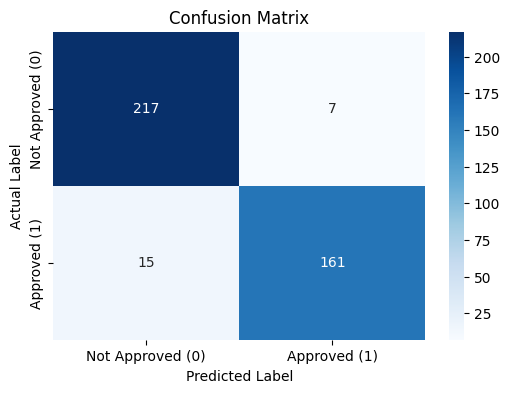

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved (0)', 'Approved (1)'],
            yticklabels=['Not Approved (0)', 'Approved (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

**b) Interpret the results.**
*(Add this text to a Markdown cell in your Colab Notebook)*

* **True Positives (TP):** The model correctly predicted that a loan would be approved.
* **True Negatives (TN):** The model correctly predicted that a loan would NOT be approved.
* **False Positives (FP):** The model predicted the loan would be approved, but it was actually rejected (Type I Error).
* **False Negatives (FN):** The model predicted the loan would be rejected, but it was actually approved (Type II Error).

---

### Q10. Model Evaluation - ROC Curve & AUC



**a) Plot the ROC curve.**
**b) Calculate the AUC score.**

AUC Score: 0.9888


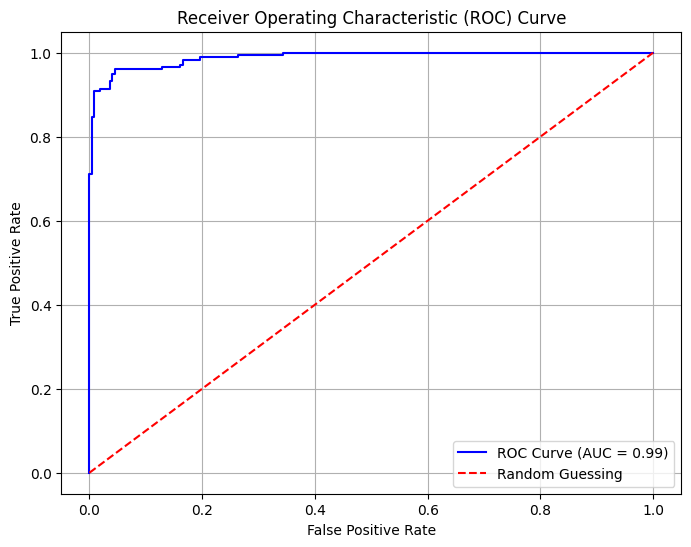

In [ ]:
# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()